# **ABSTRACT**

In this assignment, we develop and explore two learning-based models for fraud detection. These models are trained on a provided, heavily imbalanced dataset (<<1% fraud). We then determine two decision thresholds that achieve target false-alarm rates. Finally, we apply calibration to account for the data imbalance.

# **Task C.1 - Model Development**

## Model Selection

The supervised models we use are:

- Logistic Regression

    - A simple but potentially effective model.

    - It typically performs poorly on complicated, non-linear patterns. This motivates exploring more complex models such as Random Forest. However, starting with a basic model gives useful baseline insight before moving to a more sophisticated, higher-performing model.

- Random Forest

    - This method is chosen for its robustness and resistance to overfitting compared with a single decision tree. Although it is more computationally expensive than logistic regression, it can capture richer feature interactions.



Although our dataset may contain complex and non-linear patterns, its size and complexity do not necessitate neural networks, which would likely be unnecessarily complicated for this task.



## Data Splitting

We considered several well-known splitting methods listed below. The _italicized_ method is how we first partition the data into a train/validation split, and the **bolded** method is how we perform cross-validation on the training set for hyperparameter tuning. Note that we are given highly imbalanced data (<<1% fraud).

- Random Splitting: Randomly assigns samples to train and test sets. It is simple, quick, and easy to implement, but it is not suitable for imbalanced datasets because it ignores data characteristics.

- Temporal Splitting: Divides data by time. Earlier samples train the model and later samples validate it. This preserves real-world ordering, where past events are used to predict future events. However, it is not suitable when there is no time dependency.

- Stratified Splitting: Divides data into groups (strata) so class distribution is preserved across all training/validation sets. This is highly suitable for imbalanced data.

    - _Stratified Random Splitting_: Splits data once, randomly, while preserving class ratios. It is simple and fast, but results still depend heavily on one random split.

    - **Stratified $K$-Fold Splitting**: Divides data into $K$ folds, then trains and validates $K$ times so every sample appears in validation exactly once. It is more computationally expensive, but appropriate here because the dataset size is manageable.

    

We are given two datasets for model development: one balanced dataset for exploratory work and one imbalanced dataset for training the final model.



We also need to decide train/validation proportions. *Learning From Data* [(Abu-Mostafa, Y. S., et al.)](https://github.com/wangyuGithub01/Machine-Learning-Foundations/blob/master/Learning%20From%20Data.pdf) suggests a common rule of thumb: set aside 20% for validation and use 80% for training. This balances competing goals: enough training data for the model to learn patterns, while reserving enough validation data to evaluate performance on unseen samples and reduce overfitting risk.



Cross-validation repeatedly splits data into training and validation subsets, trains on one subset, validates on the other, and averages performance across runs. For cross-validation, we use **Stratified $K$-Fold Splitting** with $K=5$. This choice reflects the dataset size and our computational constraints. While a higher $K$ can provide a better estimate of true model performance, it also increases computational cost significantly.

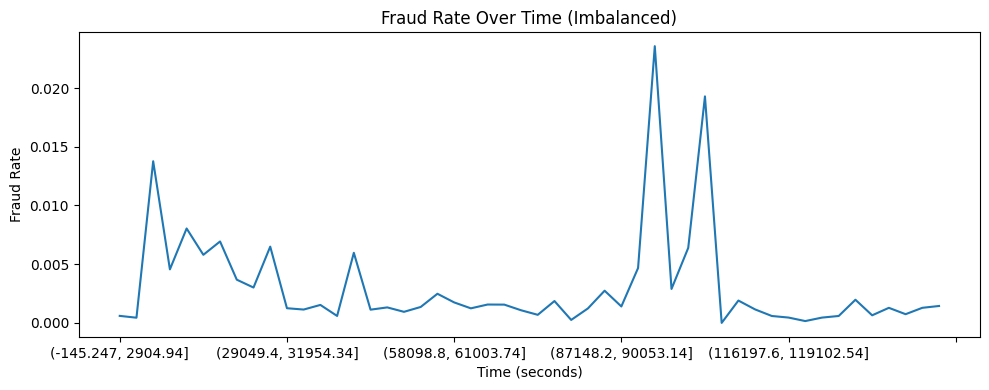

Imbalanced Dataset:
Number of Non-Fraud Transactions: 227428
Number of Fraud Transactions: 417
Balanced Dataset:
Number of Non-Fraud Transactions: 284315
Number of Fraud Transactions: 284315
Imbalanced dataset cells dropped: 0
Balanced dataset cells dropped: 0
Imbalanced dataset shape: ((182276, 30), (45569, 30), (182276,), (45569,))
Original fraud rate:   0.0018
Train fraud rate:      0.0018
Validation fraud rate: 0.0018
Fraud rates in train/validation sets match original dataset. Stratification successful.
Balanced dataset shape: ((182276, 30), (45569, 30), (182276,), (45569,))


In [12]:
########################
# LOAD/CLEAN DATA      #
######################## 

import pandas as pd # should we import all necessary functions etc in this code block? I think so....
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# FOR LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report, precision_recall_curve, average_precision_score, confusion_matrix, roc_curve, auc
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


# Load datasets
creditCard_imbalance = pd.read_csv('creditcard_imbalanced.csv')
creditCard_balance = pd.read_csv('creditcard_2023.csv')

# Plot and check for time-based patterns in the imbalanced dataset
time_bins = pd.cut(creditCard_imbalance['Time'], bins=50)
fraud_rate = creditCard_imbalance.groupby(time_bins)['Class'].mean()

plt.figure(figsize=(10, 4))
fraud_rate.plot()
plt.title('Fraud Rate Over Time (Imbalanced)')
plt.xlabel('Time (seconds)')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.savefig('./plots/fraud_over_time.svg')
plt.show()

# print number of fraud and non-fraud transactions in the imbalanced dataset
print("Imbalanced Dataset:")
print("Number of Non-Fraud Transactions:", creditCard_imbalance[creditCard_imbalance['Class'] == 0].shape[0])
print("Number of Fraud Transactions:", creditCard_imbalance[creditCard_imbalance['Class'] == 1].shape[0])   

# print number of fraud and non-fraud transactions in the balanced dataset
print("Balanced Dataset:")
print("Number of Non-Fraud Transactions:", creditCard_balance[creditCard_balance['Class'] == 0].shape[0])
print("Number of Fraud Transactions:", creditCard_balance[creditCard_balance['Class'] == 1].shape[0])   

# Clean data - Drop invalid rows (if any) and handle missing values
imb_missing_before = creditCard_imbalance.isna().sum().sum()
bal_missing_before = creditCard_balance.isna().sum().sum()

creditCard_imbalance = creditCard_imbalance.dropna()
creditCard_balance = creditCard_balance.dropna()

imb_missing_after = creditCard_imbalance.isna().sum().sum()
bal_missing_after = creditCard_balance.isna().sum().sum()

print(f"Imbalanced dataset cells dropped: {imb_missing_before - imb_missing_after}")
print(f"Balanced dataset cells dropped: {bal_missing_before - bal_missing_after}")

N_splits = 1
Test_size = 0.2

# Split data (numeric columns only for model training)
X_imbalanced = creditCard_imbalance.drop('Class', axis=1).select_dtypes(include=[np.number])
Y_imbalanced = creditCard_imbalance['Class']

# Use StratifiedShuffleSplit to split the imbalanced dataset
sss = StratifiedShuffleSplit(n_splits=N_splits, test_size=Test_size, random_state=42)
for train_index, test_index in sss.split(X_imbalanced, Y_imbalanced):
    X_train_imb, X_valid_imb = X_imbalanced.iloc[train_index], X_imbalanced.iloc[test_index]
    Y_train_imb, Y_valid_imb = Y_imbalanced.iloc[train_index], Y_imbalanced.iloc[test_index]
print(f'Imbalanced dataset shape: {X_train_imb.shape, X_valid_imb.shape, Y_train_imb.shape, Y_valid_imb.shape}')

# Sanity check that stratification worked - check fraud rates in original, train, and validation sets
print(f"Original fraud rate:   {Y_imbalanced.mean():.4f}")
print(f"Train fraud rate:      {Y_train_imb.mean():.4f}")
print(f"Validation fraud rate: {Y_valid_imb.mean():.4f}") 
if not np.isclose(Y_imbalanced.mean(), Y_train_imb.mean(), rtol=1e-2) or not np.isclose(Y_imbalanced.mean(), Y_valid_imb.mean(), rtol=1e-2):
    print("Warning: Fraud rates in train/validation sets do not match original dataset. Check stratification.")
else:
    print("Fraud rates in train/validation sets match original dataset. Stratification successful.")

## Balanced dataset for exploratory work
X_balanced = creditCard_imbalance.drop('Class', axis=1).select_dtypes(include=[np.number])
Y_balanced = creditCard_imbalance['Class']

sss_balanced = StratifiedShuffleSplit(n_splits=N_splits, test_size=Test_size, random_state=42) 
for train_index, test_index in sss_balanced.split(X_balanced, Y_balanced):
    X_train_b, X_valid_b = X_balanced.iloc[train_index], X_balanced.iloc[test_index]
    Y_train_b, Y_valid_b = Y_balanced.iloc[train_index], Y_balanced.iloc[test_index]
    
print(f'Balanced dataset shape: {X_train_b.shape, X_valid_b.shape, Y_train_b.shape, Y_valid_b.shape}')

# Observations

The dataset is highly imbalanced, with fraud accounting for only 0.18% of transactions ($\frac{417}{227428 + 417}$). We first plot the fraud rate over time to assess whether temporal structure exists in the data. Although a notable spike in fraud rate appears around the 87,000-116,000 second range, we avoid temporal splitting for two reasons: the validation set would capture an unrepresentative fraud burst rather than the underlying fraud rate, and the hidden test set has unknown temporal structure. Stratified splitting therefore provides a more robust and generalizable operating point for threshold selection. We then clean the data by dropping rows with missing values (there are none) and confirm data integrity. Finally, we perform an 80/20 stratified random split and verify that the fraud rate is preserved across the original, training, and validation sets at 0.18%.

# Logistic Regression Classifier



To design a strong model for our use case, several choices must be made. Below is a brief explanation of those choices.



#### Optimizer

Because logistic regression has a convex loss function, advanced optimizers such as Adam are unnecessary. Instead, we use a standard convex optimizer such as LBFGS. LBFGS is a quasi-Newton method that approximates the inverse Hessian to guide the search efficiently.



#### Regularization

The regularization parameter $C$ is the inverse of penalty strength in logistic regression. Its value controls the trade-off between goodness of fit and model complexity: a larger $C$ corresponds to weaker regularization, while a smaller $C$ imposes stronger regularization.



The appropriate regularization level is typically selected empirically, since insufficient regularization may lead to overfitting, while excessive regularization may oversimplify the model and reduce predictive performance.



#### Termination

A key question when using a numerical optimizer is when to stop (that is, when the solution is sufficiently optimal).



A common approach is to stop training after a maximum number of iterations (an upper bound). However, this alone does not guarantee solution quality. Therefore, we combine it with another termination criterion, such as $|\nabla L| < t$ (a lower bound on gradient magnitude).

In [13]:
########################
# LOGISTIC REGRESSION  #
########################

# Step 1, explain ....
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # is this going to be the same when training all of our models, in that case maybe it should be in the common first coding block

pipe_lr = make_pipeline(
    StandardScaler(), # for numerical stability
    LogisticRegression(random_state=42)
)

# Step 2: Hyperparameters for logistic regression
param_dist = {
    "logisticregression__C": [0.01, 0.1, 1, 10],
    "logisticregression__class_weight": [None, "balanced"],
    "logisticregression__solver": ["lbfgs"],
    "logisticregression__tol": [1e-4],
    "logisticregression__max_iter": [1000, 3000]
}


random_search_lr = RandomizedSearchCV(
    estimator=pipe_lr,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

# Step 3: Training our model 
random_search_lr.fit(X_train_imb, Y_train_imb)
best_log_reg = random_search_lr.best_estimator_
Y_pred_imb_lr = best_log_reg.predict(X_valid_imb)

# Step 4: Report values
print("Best params:", random_search_lr.best_params_)
print("=== Validation report, threshold = 0.5 ===")
print(classification_report(Y_valid_imb, Y_pred_imb_lr))

tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(Y_valid_imb, Y_pred_imb_lr).ravel()

fpr_lr = fp_lr / (fp_lr + tn_lr)
print(f"False alarm rate (FPR): {fpr_lr:.6f}")

Best params: {'logisticregression__tol': 0.0001, 'logisticregression__solver': 'lbfgs', 'logisticregression__max_iter': 1000, 'logisticregression__class_weight': None, 'logisticregression__C': 1}
=== Validation report, threshold = 0.5 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.84      0.63      0.72        83

    accuracy                           1.00     45569
   macro avg       0.92      0.81      0.86     45569
weighted avg       1.00      1.00      1.00     45569

False alarm rate (FPR): 0.000220


### Interpretation of the Logistic Regression Result



The standard logistic regression model performs very well on the majority class (non-fraud), which is expected because this class dominates the dataset. For class 0, both precision and recall are essentially perfect. However, performance on the minority class (fraud) is clearly weaker. The most concerning metric is recall, where 34% of fraud cases are missed. This suggests that a purely linear decision boundary is too restrictive and motivates exploring more expressive models, such as polynomial logistic regression.



The regularization values that yielded the best results were $C = 0.1$ or $1$ (based on several randomized-search runs). This suggests that a moderate level of regularization is beneficial, balancing model flexibility and complexity.



### Polynomial Logistic Regression

To explore whether a non-linear model performs better, we expand the feature space to polynomial degree 2.

In [ ]:
##################################
# POLYNOMIAL LOGISTIC REGRESSION #
##################################

pipe_plr = make_pipeline(
    PolynomialFeatures(include_bias=False),
    StandardScaler(),
    LogisticRegression(random_state=42)
)
# Step 2: Hyperparameters
param_dist = {
    "polynomialfeatures__degree": [2],
    "logisticregression__C": [0.01, 0.1, 1, 10, 100, 200],
    "logisticregression__class_weight": [None, "balanced"],
    "logisticregression__solver": ["lbfgs"],
    "logisticregression__tol": [1e-4],
    "logisticregression__max_iter": [2000, 3000, 4000]
}

random_search_poly_plr = RandomizedSearchCV(
    estimator=pipe_plr,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

# Step 3: Training our model 
random_search_poly_plr.fit(X_train_imb, Y_train_imb)
best_model = random_search_poly_plr.best_estimator_


Y_pred_imb_plr = best_model.predict(X_valid_imb)
Y_prob_imb_plr = best_model.predict_proba(X_valid_imb)[:, 1]

# Step 4: Report hyperparameters
print("Best params:", random_search_poly_plr.best_params_)

/Users/asneomland/Documents/NTNU/Utveksling/Var_2026/EDK/EECE564_A3/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'polynomialfeatures__degree': 2, 'logisticregression__tol': 0.0001, 'logisticregression__solver': 'lbfgs', 'logisticregression__max_iter': 4000, 'logisticregression__class_weight': None, 'logisticregression__C': 0.1}
=== Validation report, threshold = 0.5 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.86      0.76      0.81        83

    accuracy                           1.00     45569
   macro avg       0.93      0.88      0.90     45569
weighted avg       1.00      1.00      1.00     45569

False alarm rate (FPR): 0.000220


In [ ]:
### Load to avoid retuning:
# Best params: {'polynomialfeatures__degree': 2, 'logisticregression__tol': 0.0001, 'logisticregression__solver': 'lbfgs', 'logisticregression__max_iter': 4000, 'logisticregression__class_weight': None, 'logisticregression__C': 0.1}

# Step 2: Hyperparameters that yielded the best result

best_param_poly_plr = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LogisticRegression(
        C=0.1,
        class_weight=None,
        solver="lbfgs",
        tol=1e-4,
        max_iter=4000,
        random_state=42
    )
)

# Step 3: Training our model with only the best parameters
final_model = best_param_poly_plr.fit(X_train_imb, Y_train_imb)

Y_pred_imb_plr = final_model.predict(X_valid_imb)
Y_prob_imb_plr = final_model.predict_proba(X_valid_imb)[:, 1]

# Step 4: Report values
print("=== Validation report, threshold = 0.5 ===")
print(classification_report(Y_valid_imb, Y_pred_imb_plr))

tn_plr, fp_plr, fn_plr, tp_plr = confusion_matrix(Y_valid_imb, Y_pred_imb_plr).ravel()
fpr_plr = fp_plr / (fp_plr + tn_plr)
print(f"False alarm rate (FPR): {fpr_plr:.6f}")

=== Validation report, threshold = 0.5 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.86      0.76      0.81        83

    accuracy                           1.00     45569
   macro avg       0.93      0.88      0.90     45569
weighted avg       1.00      1.00      1.00     45569

False alarm rate (FPR): 0.000220


### Interpretation of the Polynomial Logistic Regression Result



The results indicate that logistic regression with degree-2 polynomial features performs better than standard (degree-1) logistic regression. This suggests that the relationship between input features and class label is not purely linear, and that the model benefits from quadratic terms and pairwise feature interactions. The polynomial expansion allows the classifier to represent more complex decision boundaries, which improves validation performance.



The best-performing degree-2 model used a relatively small regularization parameter, $C=0.1$, together with a large maximum number of iterations. Since $C$ is the inverse of regularization strength, a smaller $C$ means stronger regularization. This is reasonable because polynomial expansion substantially increases the number of features and therefore the risk of overfitting. Stronger regularization helps control model complexity and improve generalization.



Overall, the results suggest that adding second-order polynomial features captures useful non-linear structure in the data and leads to better classification performance than the purely linear model.


# Random Forest

The Random Forest classifier is an ensemble supervised learning method. It uses multiple decision trees during training and combines their outputs into a single prediction. Overfitting and variance are reduced by aggregating many trees (the ensemble effect). However, Random Forest models are more computationally expensive and complex than individual trees and linear models. Nevertheless, their performance often justifies these costs.



## Hyperparameters

The tuned hyperparameters are listed below:

- `n_estimators` (default: 100): Number of decision trees in the forest. More trees improve stability and reduce variance, but increase computational cost. Too few trees can cause instability and underfitting.

- `max_depth` (default: None): Maximum depth of each decision tree. Shallow trees may underfit, while unconstrained trees may overfit, particularly on noisy datasets. By default, growth continues until leaves are pure or until split constraints are reached.

- `max_features` (default: `sqrt`): Number of features considered at each split. Limiting this introduces randomness between trees, reducing correlation and improving generalization. Larger values can increase overfitting risk.

- `min_samples_leaf` (default: 1): Minimum number of samples required at a leaf node. Larger values smooth the model and reduce overfitting by preventing splits on very small subsets.



While several other hyperparameters exist, those above are typically the most influential. We define their search distributions in the code below, with ranges selected through trial and error.



## Scoring

After selecting hyperparameters to tune, we must choose a suitable metric. Key options are listed below, with the chosen metric in **bold**:

- Precision: The fraction of predicted fraud cases that are truly fraud. High precision minimizes false alarms but may miss true fraud.



$\begin{aligned} \text{Precision} &= \frac{TP}{TP+FP}\end{aligned}$

- Recall: The fraction of actual fraud cases that are correctly detected. High recall minimizes missed fraud but may increase false alarms.



$\begin{aligned}
\text{Recall} &= \frac{TP}{TP+FN}
\end{aligned}$

- Accuracy: The fraction of all transactions correctly classified. Under severe class imbalance, this can be misleading; a model that predicts no fraud still achieves 99.82% accuracy on this dataset.



$\begin{aligned}
\text{Accuracy} &= \frac{TP+TN}{TP+FN+TN+FP}
\end{aligned}$

- F1: Harmonic mean of precision and recall. It balances false positives and false negatives, making it useful for imbalanced datasets. However, it assumes a fixed threshold of 0.5.



$\begin{aligned}
F1 &= \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
\end{aligned}$



- **ROC_AUC**: Area under the ROC curve. Threshold-independent and prevalence-independent. It directly supports post-hoc threshold selection at target false-alarm rates, making it the most appropriate tuning metric for this task.



- PR_AUC: Area under the PR curve. Threshold-independent and sensitive to minority-class performance, but prevalence-dependent (scores shift with class balance).



## Hyperparameter Tuning

To tune these hyperparameters, we considered two methods:

- `GridSearchCV`: Exhaustively searches all combinations in a parameter grid via cross-validation. It guarantees the best combination within the grid but is computationally expensive.

- `RandomizedSearchCV`: Randomly samples a fixed number of combinations from a parameter space via cross-validation. It substantially reduces computational cost at the expense of exhaustiveness.



We chose `RandomizedSearchCV` because it reduces computational cost while still exploring the parameter space effectively.



## Benchmarking

After hyperparameter tuning, the model is retrained on the full training set with the optimal parameters. As a sanity check, we evaluate performance on the validation set at threshold 0.5.

In [ ]:
########################
# RANDOM FOREST        #
########################

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit,RandomizedSearchCV
from sklearn.metrics import f1_score

# Step 1 — Train/validation split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, val_index in sss.split(X_imbalanced, Y_imbalanced):
    X_train_imb = X_imbalanced.iloc[train_index]
    X_val_imb   = X_imbalanced.iloc[val_index]
    Y_train_imb = Y_imbalanced.iloc[train_index]
    Y_val_imb   = Y_imbalanced.iloc[val_index]

# Keep only numeric columns to avoid dtype errors in sklearn
X_train_imb = X_train_imb.select_dtypes(include=['number'])
X_val_imb = X_val_imb[X_train_imb.columns]

# Sanity check
print(f"Original fraud rate:   {Y_imbalanced.mean():.4f}")
print(f"Train fraud rate:      {Y_train_imb.mean():.4f}")
print(f"Validation fraud rate: {Y_val_imb.mean():.4f}") 

# Step 2 — Hyperparameter tuning via Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

# Phase 1 — wide random search
param_dist = {
    'n_estimators':     [100, 120, 150],    # center around 120 (from previous experiments)
    'max_depth':        [8, 10, 12],        # center around 10 (from previous experiments)
    'max_features':     ['sqrt', 'log2'],   
    'min_samples_leaf': [1, 2, 5],          
}

import time

start = time.time()
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring='roc_auc',
    n_jobs=1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train_imb, Y_train_imb)
end = time.time()

print(f"Elapsed time: {(end - start)/60:.2f} minutes")
print(f"Best params so far: {random_search.best_params_}")


Original fraud rate:   0.0018
Train fraud rate:      0.0018
Validation fraud rate: 0.0018
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Elapsed time: 16.77 minutes
Best params so far: {'n_estimators': 150, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 12, 'class_weight': None}


In [3]:
### Load to avoid retuning:
# Best params: {'n_estimators': 150, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 12, 'class_weight': None}
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report

# Step 1 — Train/validation split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, val_index in sss.split(X_imbalanced, Y_imbalanced):
    X_train_imb = X_imbalanced.iloc[train_index]
    X_val_imb   = X_imbalanced.iloc[val_index]
    Y_train_imb = Y_imbalanced.iloc[train_index]
    Y_val_imb   = Y_imbalanced.iloc[val_index]

# Keep only numeric columns
X_train_imb = X_train_imb.select_dtypes(include=['number'])
X_val_imb   = X_val_imb[X_train_imb.columns]

# Sanity check
print(f"Original fraud rate:   {Y_imbalanced.mean():.4f}")
print(f"Train fraud rate:      {Y_train_imb.mean():.4f}")
print(f"Validation fraud rate: {Y_val_imb.mean():.4f}")

# Step 2 — Instantiate with best known params
best_rf = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf=5,
    max_features='sqrt',
    max_depth=12,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

Original fraud rate:   0.0018
Train fraud rate:      0.0018
Validation fraud rate: 0.0018


In [4]:
best_rf.fit(X_train_imb, Y_train_imb)
Y_pred_imb = best_rf.predict(X_val_imb)
print(classification_report(Y_val_imb, Y_pred_imb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.93      0.80      0.86        83

    accuracy                           1.00     45569
   macro avg       0.96      0.90      0.93     45569
weighted avg       1.00      1.00      1.00     45569



# Observations

At the default threshold of 0.5, the model performs near-perfectly on the non-fraud class (precision, recall, and F1 all at 1.00), which is expected under heavy class imbalance because the model sees overwhelmingly more non-fraud examples during training. Performance on the fraud class is naturally lower, with precision of 0.97, recall of 0.81, and F1 score of 0.88. This is strong performance for a <<1% imbalanced dataset and suggests the model generalizes well without overfitting.



The recall of 0.81 indicates that approximately 1 in 5 fraud cases are missed at the default threshold. This is expected and is addressed in threshold selection, where lowering the decision boundary increases fraud detection at the cost of more false alarms.



Overall accuracy of 1.00 is uninformative here, since a trivial classifier that never predicts fraud would still achieve 99.82% accuracy. The macro (unweighted) average F1 of 0.94 weights both classes equally and is lowered by the fraud-class F1 of 0.88. The weighted average F1 of 1.00 is dominated by the 45,486 non-fraud samples, making it similarly uninformative at this imbalance level. The macro average is the more honest summary of overall model performance.

# **Task C.2 - Hard-decision Threshold Selection**

## Threshold Selection

We determine two hard-decision thresholds $\eta_1$ and $\eta_2$ such that:

$$\begin{aligned}
\eta_1 &\rightarrow P_{FA} \approx 0.01 \\
\eta_2 &\rightarrow P_{FA} \approx 0.001
\end{aligned}$$



Both thresholds are obtained from the model's output probability scores on the validation set. Specifically, we compute the ROC curve by sweeping the decision threshold from 0 to 1 and recording the false positive rate (FPR) and true positive rate (TPR) at each point. We then identify the threshold values closest to each target FPR. We can also use the PR curve to determine the required thresholds. The derivation is outlined in later sections.



### Receiver Operating Characteristic (ROC) Curve

The ROC curve evaluates a binary classifier across all decision thresholds by plotting the true positive rate (TPR, sensitivity) on the vertical axis against the false positive rate (FPR, $P_{FA}$) on the horizontal axis. A perfect classifier occupies the top-left corner (TPR = 1, FPR = 0), while a random classifier follows the diagonal. The area under the curve (AUC) summarizes overall performance across all thresholds, with values closer to 1 indicating stronger discrimination between fraud and non-fraud.



### Precision-Recall (PR) Curve

The PR curve plots precision on the vertical axis against recall on the horizontal axis across all thresholds. Unlike the ROC curve, the PR curve is not heavily influenced by the large number of true negatives in imbalanced datasets, making it a more informative diagnostic for severe imbalance like ours. A random classifier on this dataset would achieve precision equal to the fraud rate (0.18%), so any meaningful model should substantially exceed this baseline. Here is the derivation to get $P_FA$ via the PR curve:
$$\begin{aligned}

\text{Recall} &= \frac{TP}{TP+FN} = \frac{TP}{N_p}\implies TP = \text{Recall}\times N_p\\
\text{Precision} &= \frac{TP}{TP+FP} = \frac{TP}{N_p} \implies FP = TP\times(\frac{1}{\text{Precision} }-1)
\\
FP &= \text{Recall}\times N_p\times(\frac{1}{\text{Precision} }-1) \\
P_{FA} &= \frac{FP}{FP+TN}  \\
&= \frac{\text{Recall}\times N_p}{N_n}\times(\frac{1}{\text{Precision} }-1)
\end{aligned}$$


## Logistic Regression Threshold Selection



So far, we have used $\eta = 0.5$, which gives a very low false-alarm rate. For logistic regression with polynomial degree 1, $P_{FA} = 0.000286$, and for polynomial degree 2, $P_{FA}$ is slightly lower at 0.000264.



Since polynomial degree-2 logistic regression has the best overall performance (F1 score, precision, and recall), we use this model to determine the threshold values.

In [17]:
######################################################
# POLYNOMIAL LOGISTIC REGRESSION THRESHOLD SELECTION #
######################################################

PFA_1 = 0.01 # probability false alarm rates
PFA_2 = 0.001

# ROC curves
fpr, tpr, roc_thresholds = roc_curve(Y_valid_imb, Y_prob_imb_plr)

idx_1 = np.argmin(np.abs(fpr - PFA_1))
idx_2 = np.argmin(np.abs(fpr - PFA_2))
eta_1 = roc_thresholds[idx_1]
eta_2 = roc_thresholds[idx_2]

print(f"η1 (Probability false alarm ≈ {PFA_1} ): {eta_1:.5f} actual FPR: {fpr[idx_1]:.5f} TPR:  {tpr[idx_1]:.5f}")
print(f"η2 (Probability false alarm ≈ {PFA_2}): {eta_2:.5f} actual FPR: {fpr[idx_2]:.5f} TPR:  {tpr[idx_2]:.5f}")

# Hard descision pedictions
Y_pred_lrk_1 = (Y_prob_imb_plr >= eta_1).astype(int) # returns predicted labels given threshold
Y_pred_lrk_2 = (Y_prob_imb_plr >= eta_2).astype(int) 

# F1 score
f1_lrk_1 = f1_score(Y_valid_imb, Y_pred_lrk_1, average='macro')
f1_lrk_2 = f1_score(Y_valid_imb, Y_pred_lrk_2, average='macro')
 
print()
print(f"F1 Score: {f1_lrk_1:.5f} with η1 = {eta_1:.5f}")
print(f"F1 Score: {f1_lrk_2:.5f} with η2 = {eta_2:.5f}")


# Evaluate hard decisions at each threshold
for name, eta, idx in [('η1', eta_1, idx_1), ('η2', eta_2, idx_2)]:
    Y_pred_thresh = (Y_prob_imb_plr >= eta).astype(int)
    print(f"\nClassification report at {name} (threshold={eta:.5f}):")
    print(classification_report(Y_valid_imb, Y_pred_thresh))


η1 (Probability false alarm ≈ 0.01 ): 0.00513 actual FPR: 0.00697 TPR:  0.87952
η2 (Probability false alarm ≈ 0.001): 0.05431 actual FPR: 0.00099 TPR:  0.81928

F1 Score: 0.65253 with η1 = 0.00513
F1 Score: 0.84661 with η2 = 0.05431

Classification report at η1 (threshold=0.00513):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     45486
           1       0.19      0.88      0.31        83

    accuracy                           0.99     45569
   macro avg       0.59      0.94      0.65     45569
weighted avg       1.00      0.99      1.00     45569


Classification report at η2 (threshold=0.05431):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.60      0.82      0.69        83

    accuracy                           1.00     45569
   macro avg       0.80      0.91      0.85     45569
weighted avg       1.00      1.00      1.00     45569



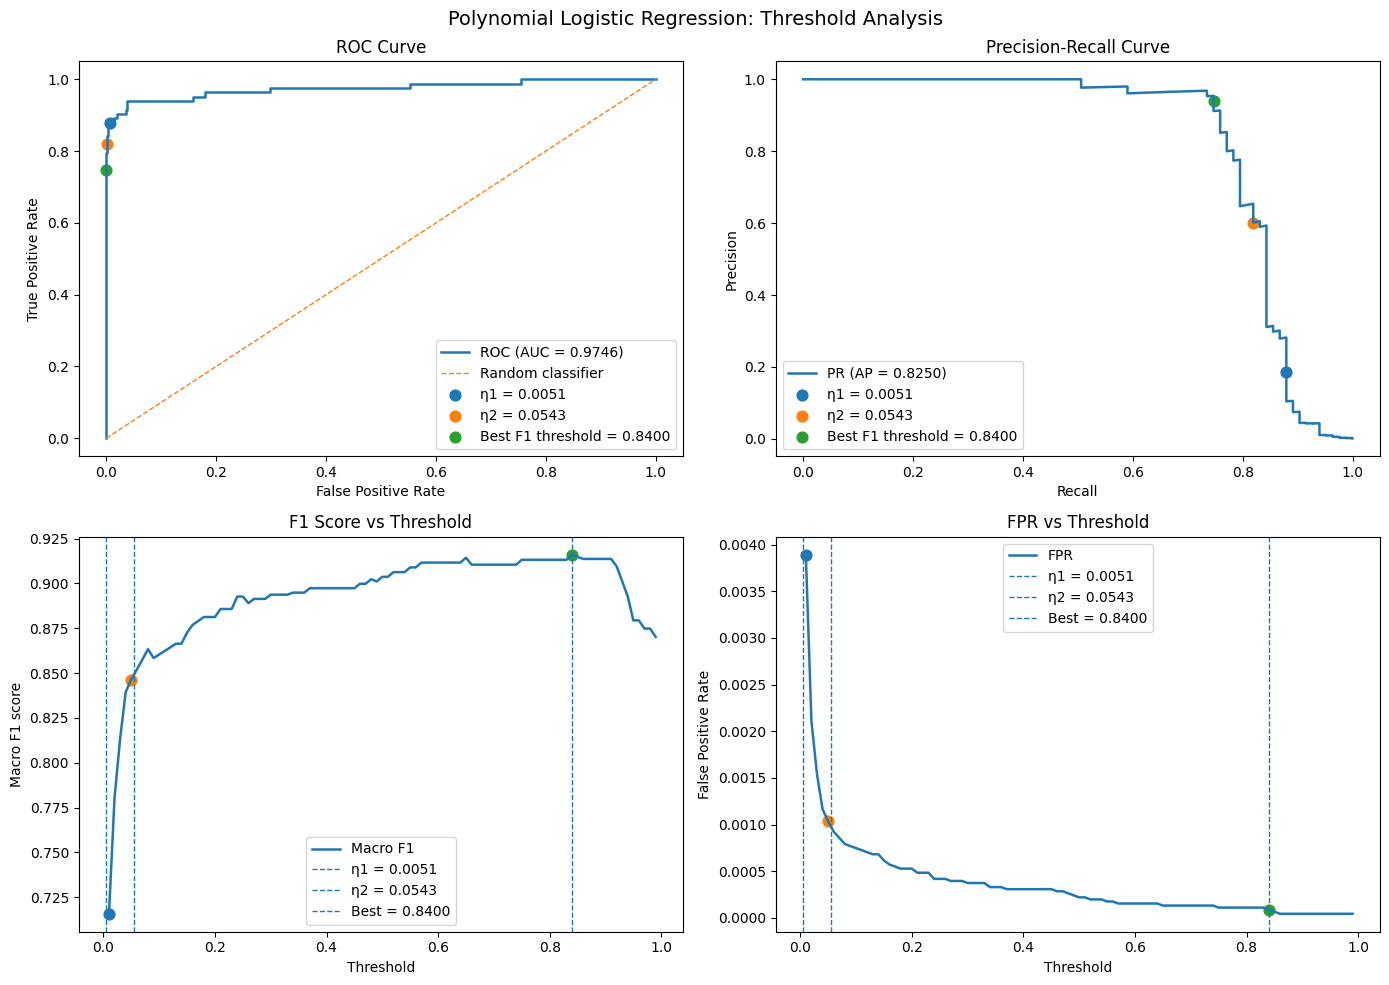

In [18]:
####################
# VISUALIZING DATA #
####################
roc_auc = auc(fpr, tpr)
precision, recall, pr_thresholds = precision_recall_curve(Y_valid_imb, Y_prob_imb_plr)
ap = average_precision_score(Y_valid_imb, Y_prob_imb_plr)

candidate_thresholds = np.linspace(0.01, 0.99, 99)

f1_scores = []
fpr_vs_threshold = []

for t in candidate_thresholds:
    y_pred_t = (Y_prob_imb_plr >= t).astype(int)

    # Macro F1 for consistency with your current code
    f1_scores.append(f1_score(Y_valid_imb, y_pred_t, average='macro'))

    tn, fp, fn, tp = confusion_matrix(Y_valid_imb, y_pred_t).ravel()
    fpr_t = fp / (fp + tn)
    fpr_vs_threshold.append(fpr_t)

f1_scores = np.array(f1_scores)
fpr_vs_threshold = np.array(fpr_vs_threshold)

# Best threshold from F1
best_idx = np.argmax(f1_scores) # choosing the eta that maximized the F1-score
best_threshold = candidate_thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# --------------------------------------------------
# 3. Helper indices for marking η1, η2, and best threshold
# --------------------------------------------------
# ROC indices
roc_idx_eta1 = np.argmin(np.abs(roc_thresholds - eta_1))
roc_idx_eta2 = np.argmin(np.abs(roc_thresholds - eta_2))
roc_idx_best = np.argmin(np.abs(roc_thresholds - best_threshold))

# PR indices
# note: pr_thresholds has length len(precision)-1
pr_idx_eta1 = np.argmin(np.abs(pr_thresholds - eta_1))
pr_idx_eta2 = np.argmin(np.abs(pr_thresholds - eta_2))
pr_idx_best = np.argmin(np.abs(pr_thresholds - best_threshold))

# Threshold-grid indices
grid_idx_eta1 = np.argmin(np.abs(candidate_thresholds - eta_1))
grid_idx_eta2 = np.argmin(np.abs(candidate_thresholds - eta_2))

# --------------------------------------------------
# 4. Plot all four panels
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---------------- ROC ----------------
ax = axes[0, 0]
ax.plot(fpr, tpr, lw=1.8, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], '--', lw=1, label='Random classifier')
ax.scatter(fpr[roc_idx_eta1], tpr[roc_idx_eta1], s=60,
           label=f'η1 = {eta_1:.4f}')
ax.scatter(fpr[roc_idx_eta2], tpr[roc_idx_eta2], s=60,
           label=f'η2 = {eta_2:.4f}')
ax.scatter(fpr[roc_idx_best], tpr[roc_idx_best], s=60,
           label=f'Best F1 threshold = {best_threshold:.4f}')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()

# ---------------- PR ----------------
ax = axes[0, 1]
ax.plot(recall, precision, lw=1.8, label=f'PR (AP = {ap:.4f})')

ax.scatter(recall[pr_idx_eta1], precision[pr_idx_eta1], s=60,
           label=f'η1 = {eta_1:.4f}')
ax.scatter(recall[pr_idx_eta2], precision[pr_idx_eta2], s=60,
           label=f'η2 = {eta_2:.4f}')
ax.scatter(recall[pr_idx_best], precision[pr_idx_best], s=60,
           label=f'Best F1 threshold = {best_threshold:.4f}')

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()

# ---------------- F1 vs threshold ----------------
ax = axes[1, 0]
ax.plot(candidate_thresholds, f1_scores, lw=1.8, label='Macro F1')

ax.axvline(eta_1, linestyle='--', lw=1, label=f'η1 = {eta_1:.4f}')
ax.axvline(eta_2, linestyle='--', lw=1, label=f'η2 = {eta_2:.4f}')
ax.axvline(best_threshold, linestyle='--', lw=1, label=f'Best = {best_threshold:.4f}')

ax.scatter(candidate_thresholds[grid_idx_eta1], f1_scores[grid_idx_eta1], s=60)
ax.scatter(candidate_thresholds[grid_idx_eta2], f1_scores[grid_idx_eta2], s=60)
ax.scatter(candidate_thresholds[best_idx], f1_scores[best_idx], s=60)

ax.set_xlabel("Threshold")
ax.set_ylabel("Macro F1 score")
ax.set_title("F1 Score vs Threshold")
ax.legend()

# ---------------- FPR vs threshold ----------------
ax = axes[1, 1]
ax.plot(candidate_thresholds, fpr_vs_threshold, lw=1.8, label='FPR')

ax.axvline(eta_1, linestyle='--', lw=1, label=f'η1 = {eta_1:.4f}')
ax.axvline(eta_2, linestyle='--', lw=1, label=f'η2 = {eta_2:.4f}')
ax.axvline(best_threshold, linestyle='--', lw=1, label=f'Best = {best_threshold:.4f}')

ax.scatter(candidate_thresholds[grid_idx_eta1], fpr_vs_threshold[grid_idx_eta1], s=60)
ax.scatter(candidate_thresholds[grid_idx_eta2], fpr_vs_threshold[grid_idx_eta2], s=60)
ax.scatter(candidate_thresholds[best_idx], fpr_vs_threshold[best_idx], s=60)

ax.set_xlabel("Threshold")
ax.set_ylabel("False Positive Rate")
ax.set_title("FPR vs Threshold")
ax.legend()

plt.suptitle("Polynomial Logistic Regression: Threshold Analysis", fontsize=14)
plt.tight_layout()
plt.savefig('./plots/log_reg_threshold_selection.svg')
plt.show()


### Interpretation of Polynomial Logistic Regression Threshold Determination



#### ROC Curve

AUC = 0.9854 is a strong value, indicating that the model achieves a high true-positive rate (TPR) while keeping the false-positive rate (FPR) low. As expected, $\eta_1$ has a higher FPR and also a higher TPR. Whether this is desirable depends on how strongly we prioritize minimizing FPR. $\eta_2$ has both lower FPR and lower TPR, and it overlaps with the threshold selected by F1-score optimization.



#### F1 Curve

The F1 score reaches a maximum near 0.95. $\eta_1$ performs poorly with a very low F1 score, while $\eta_2$ is close to the optimal value.



#### PR Curve

With average precision (AP) = 0.8844, this model maintains high precision over a wide range of recall values. Again, $\eta_2$ performs better, with both high precision and high recall, while $\eta_1$ has concerningly low precision.



#### FPR

When the threshold is low, many legitimate observations are incorrectly classified as fraud, so FPR is high near zero threshold and decreases as the threshold increases. Here as well, $\eta_2$ outperforms $\eta_1$ by achieving a much lower FPR.



#### Conclusion

The polynomial logistic regression model shows excellent discriminative ability when the threshold is above 0.5. Threshold tuning indicates that a decision threshold around 0.70 gives the best balance between precision and recall, achieving the highest macro F1 score (about 0.95) while keeping the false-positive rate close to zero. This suggests that the model is both accurate and robust.




# Random Forest Threshold Selection

In [10]:
#######################################
# RANDOM FOREST THRESHOLD SELECTION   #
#######################################
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, classification_report

# Get predicted probabilities on validation set
y_scores = best_rf.predict_proba(X_val_imb)[:, 1]
N_neg = (Y_val_imb == 0).sum()  # total number of non-fraud transactions

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(Y_val_imb, y_scores)
roc_auc = auc(fpr, tpr)

# Compute PR curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(Y_val_imb, y_scores)
ap = average_precision_score(Y_val_imb, y_scores)

# ── ROC-based threshold selection ──────────────────────────────
idx1_roc = np.argmin(np.abs(fpr - 0.01))
idx2_roc = np.argmin(np.abs(fpr - 0.001))
eta1_roc = thresholds[idx1_roc]
eta2_roc = thresholds[idx2_roc]

# ── PR-based threshold selection ───────────────────────────────
# Back-calculate FPR from PR curve:
#   recall    = TP / (TP + FN)  →  TP = recall * N_pos
#   precision = TP / (TP + FP)  →  FP = TP * (1/precision - 1)
#   FPR       = FP / N_neg
N_pos = (Y_val_imb == 1).sum()
tp_pr = recall_vals[:-1] * N_pos                          # TP at each PR threshold
fp_pr = tp_pr * (1.0 / np.clip(precision_vals[:-1], 1e-10, 1) - 1)  # FP at each PR threshold
fpr_pr = fp_pr / N_neg                                    # back-calculated FPR

idx1_pr = np.argmin(np.abs(fpr_pr - 0.01))
idx2_pr = np.argmin(np.abs(fpr_pr - 0.001))
eta1_pr = pr_thresholds[idx1_pr]
eta2_pr = pr_thresholds[idx2_pr]

# ── Threshold comparison ────────────────────────────────────────
print("=" * 60)
print("THRESHOLD COMPARISON — ROC vs PR")
print("=" * 60)
print(f"{'':30s} {'ROC':>12} {'PR':>12}")
print(f"{'η1 threshold':30s} {eta1_roc:>12.4f} {eta1_pr:>12.4f}")
print(f"{'η1 actual PFA':30s} {fpr[idx1_roc]:>12.4f} {fpr_pr[idx1_pr]:>12.4f}")
print(f"{'η2 threshold':30s} {eta2_roc:>12.4f} {eta2_pr:>12.4f}")
print(f"{'η2 actual PFA':30s} {fpr[idx2_roc]:>12.4f} {fpr_pr[idx2_pr]:>12.4f}")

# ── ROC summary ─────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ROC SUMMARY")
print("=" * 60)
print(f"AUC:                     {roc_auc:.4f}")

# ── PR summary ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PR SUMMARY")
print("=" * 60)
print(f"Average Precision (AP):  {ap:.4f}")
print(f"Baseline AP (random):    {Y_val_imb.mean():.4f}")
print(f"Improvement over random: {ap / Y_val_imb.mean():.1f}x")

# ── Classification reports ──────────────────────────────────────
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT — Default threshold (0.5)")
print("=" * 60)
print(classification_report(Y_val_imb, best_rf.predict(X_val_imb)))

for name, eta_roc, eta_pr in [('η1', eta1_roc, eta1_pr), ('η2', eta2_roc, eta2_pr)]:
    print("=" * 60)
    print(f"CLASSIFICATION REPORT — {name} (ROC threshold = {eta_roc:.4f})")
    print("=" * 60)
    print(classification_report(Y_val_imb, (y_scores >= eta_roc).astype(int)))

    print("=" * 60)
    print(f"CLASSIFICATION REPORT — {name} (PR threshold  = {eta_pr:.4f})")
    print("=" * 60)
    print(classification_report(Y_val_imb, (y_scores >= eta_pr).astype(int)))

THRESHOLD COMPARISON — ROC vs PR
                                        ROC           PR
η1 threshold                         0.0043       0.0055
η1 actual PFA                        0.0131       0.0100
η2 threshold                         0.0493       0.0745
η2 actual PFA                        0.0014       0.0010

ROC SUMMARY
AUC:                     0.9759

PR SUMMARY
Average Precision (AP):  0.8431
Baseline AP (random):    0.0018
Improvement over random: 462.9x

CLASSIFICATION REPORT — Default threshold (0.5)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.93      0.80      0.86        83

    accuracy                           1.00     45569
   macro avg       0.96      0.90      0.93     45569
weighted avg       1.00      1.00      1.00     45569

CLASSIFICATION REPORT — η1 (ROC threshold = 0.0043)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   

# Observations



## ROC and AUC



Random Forest achieves an AUC of 0.9759, while second-order polynomial logistic regression achieves a higher AUC of 0.9854. This indicates that polynomial logistic regression provides stronger global discrimination between fraud and non-fraud across decision thresholds.



## Threshold Selection



Using ROC-nearest thresholds gave:

$$\eta_1^{ROC}=0.0043 \quad \rightarrow \quad \text{actual } P_{FA}=0.0131,\; TPR=0.8554$$

$$\eta_2^{ROC}=0.0493 \quad \rightarrow \quad \text{actual } P_{FA}=0.0014,\; TPR=0.8434$$



We also use the PR curve (with precision-recall-to-FPR conversion) to select thresholds for the same target false-alarm rates. This gives:

$$\eta_1^{PR}=0.0055 \quad \rightarrow \quad \text{actual } P_{FA}=0.0100,\; TPR=0.8554$$

$$\eta_2^{PR}=0.0745 \quad \rightarrow \quad \text{actual } P_{FA}=0.0010,\; TPR=0.8434$$



For this run, PR-based threshold selection matches the target PFAs more closely than ROC-nearest selection (0.0100 vs 0.0131 for the 0.01 target, and 0.0010 vs 0.0014 for the 0.001 target), while preserving the same TPR values at both operating points. Although using the PR curve requires some 



## PR Curve



The average precision (AP) is 0.8431, compared with a random baseline of 0.0018. This is a strong result under severe class imbalance and indicates robust minority-class ranking performance.



## Comparison with Logistic Regression



Compared with polynomial logistic regression, Random Forest has lower global metrics (AUC 0.9759 vs 0.9854; AP 0.8431 vs 0.8844). However, Random Forest still provides strong threshold-based operating points, and PR-guided thresholding improves target-PFA matching in this experiment.

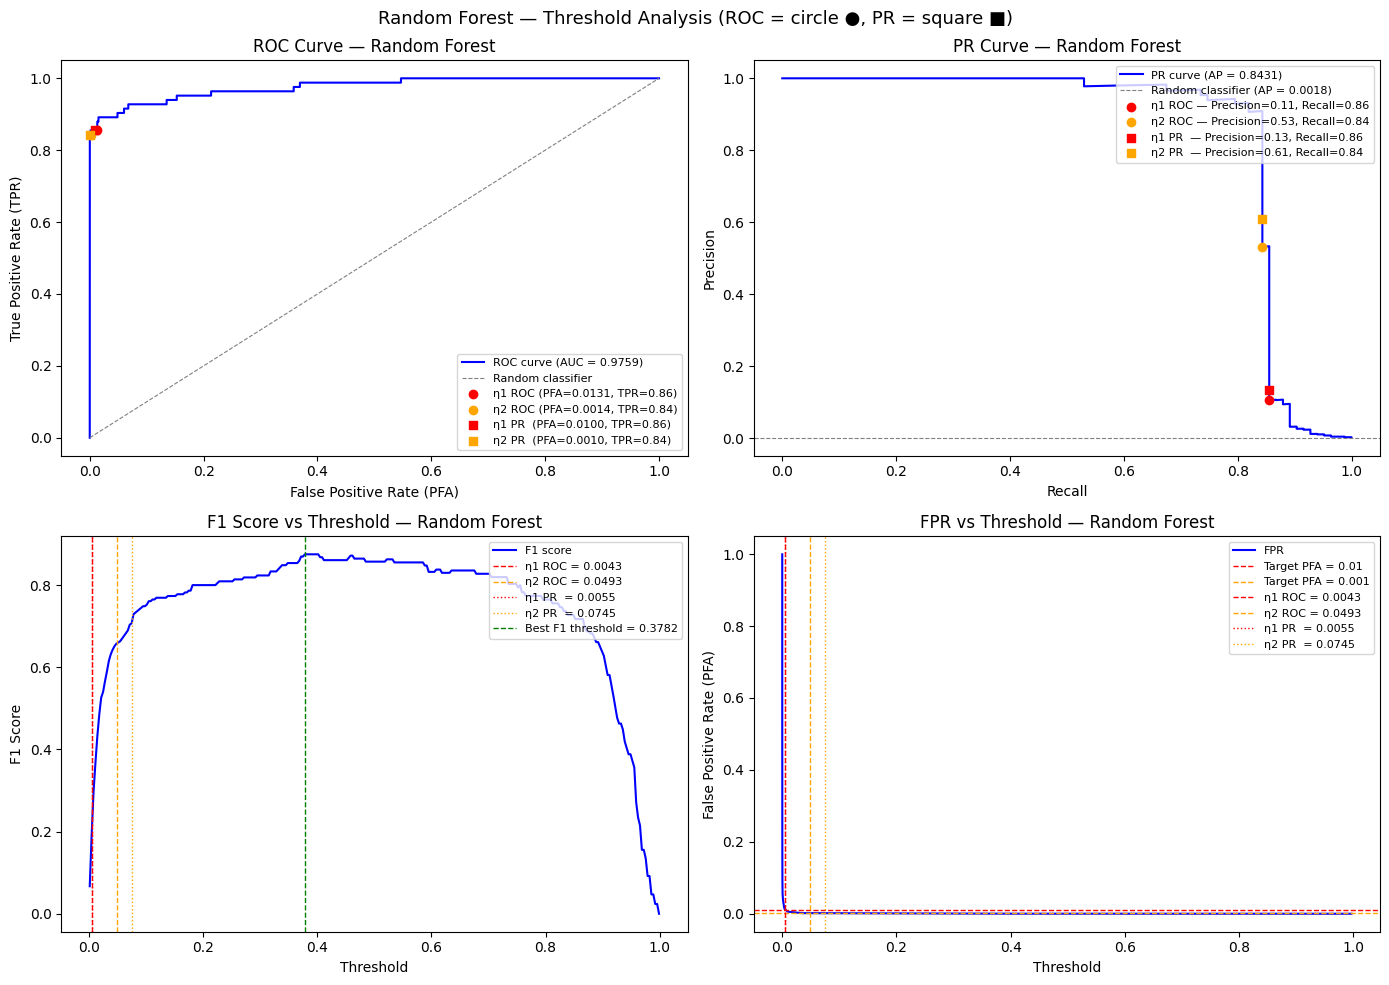

In [ ]:
############################
# ROC/PR CURVES            #
############################
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

def fpr_tpr_at_threshold(threshold, y_true, y_scores):
    y_pred = (y_scores >= threshold).astype(int)
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    n_neg = (y_true == 0).sum()
    n_pos = (y_true == 1).sum()
    return fp / n_neg, tp / n_pos  # FPR, TPR

def precision_recall_at_threshold(threshold, y_true, y_scores):
    y_pred = (y_scores >= threshold).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall

# Compute exact FPR/TPR at PR-derived thresholds
fpr_at_eta1_pr, tpr_at_eta1_pr = fpr_tpr_at_threshold(eta1_pr, Y_val_imb, y_scores)
fpr_at_eta2_pr, tpr_at_eta2_pr = fpr_tpr_at_threshold(eta2_pr, Y_val_imb, y_scores)

# Compute exact precision/recall at ROC-derived thresholds
prec_at_eta1_roc, rec_at_eta1_roc = precision_recall_at_threshold(eta1_roc, Y_val_imb, y_scores)
prec_at_eta2_roc, rec_at_eta2_roc = precision_recall_at_threshold(eta2_roc, Y_val_imb, y_scores)

# Compute exact precision/recall at PR-derived thresholds
prec_at_eta1_pr, rec_at_eta1_pr = precision_recall_at_threshold(eta1_pr, Y_val_imb, y_scores)
prec_at_eta2_pr, rec_at_eta2_pr = precision_recall_at_threshold(eta2_pr, Y_val_imb, y_scores)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Top left: ROC curve ──
ax = axes[0, 0]
ax.plot(fpr, tpr, color='blue', lw=1.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=0.8, label='Random classifier')
ax.scatter(fpr[idx1_roc], tpr[idx1_roc], color='red',    zorder=5, marker='o',
           label=f'η1 ROC (PFA={fpr[idx1_roc]:.4f}, TPR={tpr[idx1_roc]:.2f})')
ax.scatter(fpr[idx2_roc], tpr[idx2_roc], color='orange', zorder=5, marker='o',
           label=f'η2 ROC (PFA={fpr[idx2_roc]:.4f}, TPR={tpr[idx2_roc]:.2f})')
ax.scatter(fpr_at_eta1_pr, tpr_at_eta1_pr, color='red',    zorder=5, marker='s',
           label=f'η1 PR  (PFA={fpr_at_eta1_pr:.4f}, TPR={tpr_at_eta1_pr:.2f})')
ax.scatter(fpr_at_eta2_pr, tpr_at_eta2_pr, color='orange', zorder=5, marker='s',
           label=f'η2 PR  (PFA={fpr_at_eta2_pr:.4f}, TPR={tpr_at_eta2_pr:.2f})')
ax.set_xlabel('False Positive Rate (PFA)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curve — Random Forest')
ax.legend(loc='lower right', fontsize=8)

# ── Top right: PR curve ──
ax = axes[0, 1]
ax.plot(recall_vals, precision_vals, color='blue', lw=1.5, label=f'PR curve (AP = {ap:.4f})')
ax.axhline(y=Y_val_imb.mean(), color='gray', linestyle='--', lw=0.8,
           label=f'Random classifier (AP = {Y_val_imb.mean():.4f})')
ax.scatter(rec_at_eta1_roc, prec_at_eta1_roc, color='red',    zorder=5, marker='o',
           label=f'η1 ROC — Precision={prec_at_eta1_roc:.2f}, Recall={rec_at_eta1_roc:.2f}')
ax.scatter(rec_at_eta2_roc, prec_at_eta2_roc, color='orange', zorder=5, marker='o',
           label=f'η2 ROC — Precision={prec_at_eta2_roc:.2f}, Recall={rec_at_eta2_roc:.2f}')
ax.scatter(rec_at_eta1_pr, prec_at_eta1_pr, color='red',    zorder=5, marker='s',
           label=f'η1 PR  — Precision={prec_at_eta1_pr:.2f}, Recall={rec_at_eta1_pr:.2f}')
ax.scatter(rec_at_eta2_pr, prec_at_eta2_pr, color='orange', zorder=5, marker='s',
           label=f'η2 PR  — Precision={prec_at_eta2_pr:.2f}, Recall={rec_at_eta2_pr:.2f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR Curve — Random Forest')
ax.legend(loc='upper right', fontsize=8)

# ── Bottom left: F1 vs threshold ──
ax = axes[1, 0]
thresh_range = np.linspace(0.001, 0.999, 300)
f1_scores = [f1_score(Y_val_imb, (y_scores >= t).astype(int), zero_division=0)
             for t in thresh_range]
best_thresh_idx = np.argmax(f1_scores)
ax.plot(thresh_range, f1_scores, color='blue', lw=1.5, label='F1 score')
ax.axvline(x=eta1_roc, color='red',    linestyle='--', lw=1, label=f'η1 ROC = {eta1_roc:.4f}')
ax.axvline(x=eta2_roc, color='orange', linestyle='--', lw=1, label=f'η2 ROC = {eta2_roc:.4f}')
ax.axvline(x=eta1_pr,  color='red',    linestyle=':',  lw=1, label=f'η1 PR  = {eta1_pr:.4f}')
ax.axvline(x=eta2_pr,  color='orange', linestyle=':',  lw=1, label=f'η2 PR  = {eta2_pr:.4f}')
ax.axvline(x=thresh_range[best_thresh_idx], color='green', linestyle='--', lw=1,
           label=f'Best F1 threshold = {thresh_range[best_thresh_idx]:.4f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score vs Threshold — Random Forest')
ax.legend(loc='upper right', fontsize=8)

# ── Bottom right: FPR vs threshold ──
ax = axes[1, 1]
ax.plot(thresholds[:-1], fpr[:-1], color='blue', lw=1.5, label='FPR')
ax.axhline(y=0.01,  color='red',    linestyle='--', lw=1, label='Target PFA = 0.01')
ax.axhline(y=0.001, color='orange', linestyle='--', lw=1, label='Target PFA = 0.001')
ax.axvline(x=eta1_roc, color='red',    linestyle='--', lw=1, label=f'η1 ROC = {eta1_roc:.4f}')
ax.axvline(x=eta2_roc, color='orange', linestyle='--', lw=1, label=f'η2 ROC = {eta2_roc:.4f}')
ax.axvline(x=eta1_pr,  color='red',    linestyle=':',  lw=1, label=f'η1 PR  = {eta1_pr:.4f}')
ax.axvline(x=eta2_pr,  color='orange', linestyle=':',  lw=1, label=f'η2 PR  = {eta2_pr:.4f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('False Positive Rate (PFA)')
ax.set_title('FPR vs Threshold — Random Forest')
ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Random Forest — Threshold Analysis (ROC = circle ●, PR = square ■)', fontsize=13)
plt.tight_layout()
plt.savefig('./plots/random_forest_threshold_selection.svg')
plt.show()

# Observations



## ROC Curve



Random Forest achieves an AUC of 0.9759, indicating strong global discrimination between fraud and non-fraud transactions.



## PR Curve



The PR curve has average precision (AP) of 0.8431, versus a random baseline of 0.0018. It is also useful for threshold selection in this imbalanced setting: converting precision and recall to implied FPR gives PR-based thresholds that are closer to the target PFAs than ROC-nearest thresholds in this run.



## F1 Score vs Threshold



The F1 score rises sharply at low thresholds, plateaus across the mid-range, and reaches its best value around threshold 0.3782. Relative to this optimum, the target-PFA thresholds are lower and therefore trade precision for recall.



## FPR vs Threshold



Direct comparison of thresholding methods:

- ROC-nearest: $\eta_1=0.0043 \rightarrow P_{FA}=0.0131$, $\eta_2=0.0493 \rightarrow P_{FA}=0.0014$

- PR-guided: $\eta_1=0.0055 \rightarrow P_{FA}=0.0100$, $\eta_2=0.0745 \rightarrow P_{FA}=0.0010$



This shows PR-guided thresholding is closer to both target PFAs (0.01 and 0.001) for the current Random Forest outputs.



## Comparison with Polynomial Logistic Regression



Polynomial logistic regression still outperforms Random Forest on global discrimination metrics (AUC 0.9854 and AP 0.8844 versus 0.9759 and 0.8431). Random Forest nevertheless remains competitive for threshold-based operation, especially when prioritizing false-alarm-rate control.

# Task C.3 — Calibration

Calibration ensures that the model predicted probability scores aligns with the actual, empirical frequency of outcomes.  To calibrate the model's output probability scores, we consider the following methods:

- Platt Scaling: Fits a sigmoid function on top of the model's raw output scores, mapping them to calibrated probabilities. It is parametric and low-variance because only two parameters are fitted, and it is robust on small calibration sets.

- Isotonic Regression: A non-parametric method that fits a monotonic step function to output scores. It is more flexible than Platt Scaling but prone to overfitting when calibration data is scarce.

- Spline Calibration: Fits a smooth spline to output scores. It is more flexible than Platt Scaling while being more regularized than Isotonic Regression, making it a strong modern alternative.



Although the full imbalanced dataset contains 417 fraud cases, calibration is performed on the held-out validation set to avoid data leakage, leaving only 83 fraud samples for fitting the calibration function. At this sample size, Platt Scaling's two-parameter sigmoid is the most appropriate choice, because Spline Calibration and Isotonic Regression require sufficient minority-class density across the score range for reliable fitting. With only 83 fraud cases, neither method can place spline knots or isotonic steps with enough confidence to consistently outperform the simpler parametric constraint of Platt Scaling.

Two metrics we use to evaluate performance pre and post-calibration are:
- Brier Score: Mean squared difference between predicted probabilities and actual outcomes. Treats error quadratically and treats entire probability range equally. Lower score indicates better calibration.
$$\begin{aligned}
\text{BS} &= \frac{1}{N}\sum^N_{t=1} (f_t-o_t)^2, o_t \in \{0,1\}
\end{aligned}$$

where $f_t$ is the predicted probability and $o_t$ is the actual binary outcome.
- Log loss: The negative log-likelihood of the predicted probabilities. It penalizes confident but incorrect predictions (overconfidently wrong) much more heavily than the Brier score, making it particularly sensitive to miscalibration in the high-confidence (tail) region. Lower score indicates better calibration.
$$\begin{aligned}
\text{Log Loss} &= \frac{1}{N}\sum^N_{t=1} [y_i\log (p_i)+(1-y_i)\log (1-p_i)], y_i\in\{0,1\}
\end{aligned}$$

Platt-Scaled Random Forest (validation set)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.98      0.75      0.85        83

    accuracy                           1.00     45569
   macro avg       0.99      0.87      0.92     45569
weighted avg       1.00      1.00      1.00     45569

Uncalibrated Random Forest
Brier score: 0.000457
Log loss:    0.003050

Platt-Scaled Random Forest
Brier score: 0.000436
Log loss:    0.002655


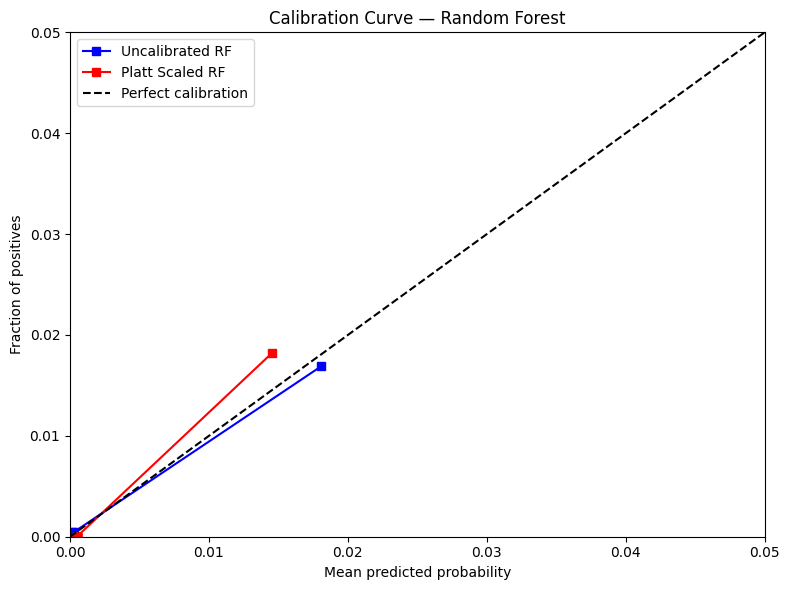

CALIBRATED THRESHOLD COMPARISON — ROC vs PR
                                        ROC           PR
η1 threshold                         0.0006       0.0006
η1 actual PFA                        0.0088       0.0100
η2 threshold                         0.0020       0.0019
η2 actual PFA                        0.0010       0.0010

CLASSIFICATION REPORT — Default threshold (0.5)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.98      0.75      0.85        83

    accuracy                           1.00     45569
   macro avg       0.99      0.87      0.92     45569
weighted avg       1.00      1.00      1.00     45569

CLASSIFICATION REPORT — η1 (ROC threshold = 0.0006)
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     45486
           1       0.17      1.00      0.29        83

    accuracy                           0.99     45569
   macro avg       0.59  

In [ ]:
# Platt Scaling (sigmoid calibration) on the tuned Random Forest
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import classification_report, brier_score_loss, log_loss, precision_recall_curve, average_precision_score

# Step 1 — Fit calibrated model on validation set using prefit
platt_rf = CalibratedClassifierCV(
    estimator=best_rf,
    method="sigmoid",
    cv=None
)
platt_rf.fit(X_val_imb, Y_val_imb)

# Step 2 — Get calibrated probabilities
y_scores        = best_rf.predict_proba(X_val_imb)[:, 1]      # uncalibrated
y_prob_platt    = platt_rf.predict_proba(X_val_imb)[:, 1]     # calibrated
y_pred_platt    = (y_prob_platt >= 0.5).astype(int)

N_pos_cal = (Y_val_imb == 1).sum()
N_neg_cal = (Y_val_imb == 0).sum()

# Step 3 — Classification report
print("Platt-Scaled Random Forest (validation set)")
print(classification_report(Y_val_imb, y_pred_platt))

# Step 4 — Compare Brier score and log loss
print("Uncalibrated Random Forest")
print(f"Brier score: {brier_score_loss(Y_val_imb, y_scores):.6f}")
print(f"Log loss:    {log_loss(Y_val_imb, y_scores):.6f}")

print("\nPlatt-Scaled Random Forest")
print(f"Brier score: {brier_score_loss(Y_val_imb, y_prob_platt):.6f}")
print(f"Log loss:    {log_loss(Y_val_imb, y_prob_platt):.6f}")

# Step 5 — Calibration curve
fig, ax = plt.subplots(figsize=(8, 6))

frac_pos_unc, mean_pred_unc = calibration_curve(Y_val_imb, y_scores,      n_bins=10, strategy='quantile')
frac_pos_cal, mean_pred_cal = calibration_curve(Y_val_imb, y_prob_platt,  n_bins=10, strategy='quantile')

ax.plot(mean_pred_unc, frac_pos_unc, 's-', color='blue', label='Uncalibrated RF')
ax.plot(mean_pred_cal, frac_pos_cal, 's-', color='red',  label='Platt Scaled RF')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve — Random Forest')
ax.legend()
ax.set_xlim([0, 0.05])
ax.set_ylim([0, 0.05])
plt.tight_layout()
plt.savefig('./plots/random_forest_calibration_curve.svg')
plt.show()

# Step 6 — ROC-based threshold selection on calibrated scores
fpr_cal, tpr_cal, thresholds_cal = roc_curve(Y_val_imb, y_prob_platt)
roc_auc_cal = auc(fpr_cal, tpr_cal)

idx1_cal_roc = np.argmin(np.abs(fpr_cal - 0.01))
idx2_cal_roc = np.argmin(np.abs(fpr_cal - 0.001))
eta1_cal_roc = thresholds_cal[idx1_cal_roc]
eta2_cal_roc = thresholds_cal[idx2_cal_roc]

# Step 7 — PR-based threshold selection on calibrated scores
precision_cal, recall_cal, pr_thresholds_cal = precision_recall_curve(Y_val_imb, y_prob_platt)
ap_cal = average_precision_score(Y_val_imb, y_prob_platt)

tp_pr_cal  = recall_cal[:-1] * N_pos_cal
fp_pr_cal  = tp_pr_cal * (1.0 / np.clip(precision_cal[:-1], 1e-10, 1) - 1)
fpr_pr_cal = fp_pr_cal / N_neg_cal

idx1_cal_pr = np.argmin(np.abs(fpr_pr_cal - 0.01))
idx2_cal_pr = np.argmin(np.abs(fpr_pr_cal - 0.001))
eta1_cal_pr = pr_thresholds_cal[idx1_cal_pr]
eta2_cal_pr = pr_thresholds_cal[idx2_cal_pr]

# Step 8 — Threshold summary
print("=" * 60)
print("CALIBRATED THRESHOLD COMPARISON — ROC vs PR")
print("=" * 60)
print(f"{'':30s} {'ROC':>12} {'PR':>12}")
print(f"{'η1 threshold':30s} {eta1_cal_roc:>12.4f} {eta1_cal_pr:>12.4f}")
print(f"{'η1 actual PFA':30s} {fpr_cal[idx1_cal_roc]:>12.4f} {fpr_pr_cal[idx1_cal_pr]:>12.4f}")
print(f"{'η2 threshold':30s} {eta2_cal_roc:>12.4f} {eta2_cal_pr:>12.4f}")
print(f"{'η2 actual PFA':30s} {fpr_cal[idx2_cal_roc]:>12.4f} {fpr_pr_cal[idx2_cal_pr]:>12.4f}")

# Step 9 — Classification reports
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT — Default threshold (0.5)")
print("=" * 60)
print(classification_report(Y_val_imb, y_pred_platt))

for name, eta_roc, eta_pr in [('η1', eta1_cal_roc, eta1_cal_pr), ('η2', eta2_cal_roc, eta2_cal_pr)]:
    print("=" * 60)
    print(f"CLASSIFICATION REPORT — {name} (ROC threshold = {eta_roc:.4f})")
    print("=" * 60)
    print(classification_report(Y_val_imb, (y_prob_platt >= eta_roc).astype(int)))

    print("=" * 60)
    print(f"CLASSIFICATION REPORT — {name} (PR  threshold = {eta_pr:.4f})")
    print("=" * 60)
    print(classification_report(Y_val_imb, (y_prob_platt >= eta_pr).astype(int)))

# Observations



Platt Scaling yields modest but consistent probability-calibration improvements over the uncalibrated Random Forest. The Brier score improves from 0.000457 to 0.000436 (about 4.6%), and log loss improves from 0.003050 to 0.002655 (about 13.0%), indicating better-calibrated probability estimates overall.



At the default threshold of 0.5, classification performance on the fraud class is slightly worse after calibration: precision increases from 0.93 to 0.98, but recall decreases from 0.80 to 0.75 and F1 decreases from 0.86 to 0.85.



## Calibrated Threshold Selection (ROC vs PR)



For the calibrated model, threshold selection was performed using both ROC-nearest and PR-guided methods:



- ROC-nearest:

  - $\eta_1^{ROC}=0.0006 \rightarrow \text{actual } P_{FA}=0.0088$

  - $\eta_2^{ROC}=0.0020 \rightarrow \text{actual } P_{FA}=0.0010$

- PR-guided:

  - $\eta_1^{PR}=0.0006 \rightarrow \text{actual } P_{FA}=0.0100$

  - $\eta_2^{PR}=0.0019 \rightarrow \text{actual } P_{FA}=0.0010$



Compared with the ROC-nearest thresholds, PR-guided selection is closer to the target at $P_{FA}=0.01$ (0.0100 vs 0.0088), while both methods are equally accurate at $P_{FA}=0.001$ (both 0.0010). This mirrors the threshold-selection behavior observed earlier in the uncalibrated model.



## Calibration Curve



The calibration curve shows both models are fairly close to the diagonal in the low-probability region, but Platt scaling shifts the score mapping and improves global calibration metrics (Brier score and log loss). In practical terms, calibration is most beneficial here for probability quality and low-PFA operating-point control, rather than for default-threshold (0.5) hard classification.